In [2]:
import pandas as pd
import numpy as np
import ast

In [3]:
movies = pd.read_csv("tmdb_5000_movies.csv")
credits = pd.read_csv("tmdb_5000_credits.csv")

movies = movies.merge(credits, on="title")
print(movies.shape)
movies.head()

(4809, 23)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4809 non-null   int64  
 1   genres                4809 non-null   object 
 2   homepage              1713 non-null   object 
 3   id                    4809 non-null   int64  
 4   keywords              4809 non-null   object 
 5   original_language     4809 non-null   object 
 6   original_title        4809 non-null   object 
 7   overview              4806 non-null   object 
 8   popularity            4809 non-null   float64
 9   production_companies  4809 non-null   object 
 10  production_countries  4809 non-null   object 
 11  release_date          4808 non-null   object 
 12  revenue               4809 non-null   int64  
 13  runtime               4807 non-null   float64
 14  spoken_languages      4809 non-null   object 
 15  status               

,title,vote_average,popularity
546,Minions,6.4,875.581305
95,Interstellar,8.1,724.247784
788,Deadpool,7.4,514.569956
94,Guardians of the Galaxy,7.9,481.098624
127,Mad Max: Fury Road,7.2,434.278564
28,Jurassic World,6.5,418.708552
199,Pirates of the Caribbean: The Curse of the Bla...,7.5,271.972889
82,Dawn of the Planet of the Apes,7.3,243.791743
200,The Hunger Games: Mockingjay - Part 1,6.6,206.227151
88,Big Hero 6,7.8,203.734590


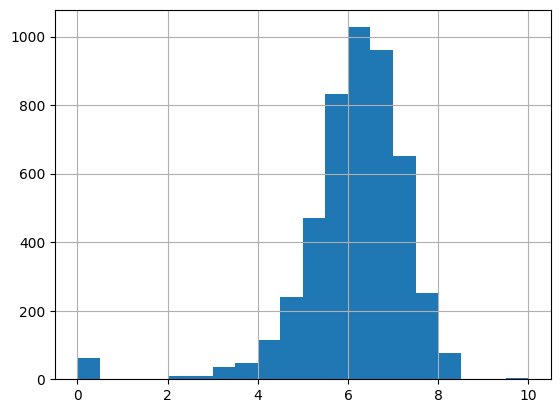

In [4]:
movies.info()
print(movies.isnull().sum())

movies['vote_average'].hist(bins=20)

movies[['title','vote_average','popularity']].sort_values(
    'popularity', ascending=False
).head(10)

In [5]:
movies = movies[['movie_id','title','overview','genres','keywords','cast','crew']]
movies.dropna(inplace=True)

In [6]:
def parse_names(text, limit=None):
    try:
        items = ast.literal_eval(text)
        names = [i['name'] for i in items]
        return names[:limit] if limit else names
    except:
        return []

movies['genres'] = movies['genres'].apply(parse_names)
movies['keywords'] = movies['keywords'].apply(parse_names)
movies['cast'] = movies['cast'].apply(lambda x: parse_names(x, limit=3))

def get_director(text):
    try:
        crew = ast.literal_eval(text)
        for member in crew:
            if member['job'] == 'Director':
                return [member['name']]
        return []
    except:
        return []

movies['crew'] = movies['crew'].apply(get_director)

In [7]:
def clean(lst):
    return [str(i).replace(" ", "").lower() for i in lst]

movies['genres'] = movies['genres'].apply(clean)
movies['keywords'] = movies['keywords'].apply(clean)
movies['cast'] = movies['cast'].apply(clean)
movies['crew'] = movies['crew'].apply(clean)
movies['overview'] = movies['overview'].apply(lambda x: x.split())

movies['tags'] = (
    movies['overview'] + movies['genres'] +
    movies['keywords'] + movies['cast'] + movies['crew']
)

final_df = movies[['movie_id','title','tags']].copy()
final_df['tags'] = final_df['tags'].apply(lambda x: " ".join(x))
final_df.head()

,movie_id,title,tags
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...
4,49529,John Carter,"John Carter is a war-weary, former military ca..."


In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(final_df['tags']).toarray()

similarity = cosine_similarity(vectors)
print(similarity.shape)

(4806, 4806)


In [9]:
def recommend(movie_title, n=5):
    if movie_title not in final_df['title'].values:
        return f"'{movie_title}' not found in dataset."

    idx = final_df[final_df['title'] == movie_title].index[0]
    distances = list(enumerate(similarity[idx]))
    distances = sorted(distances, key=lambda x: x[1], reverse=True)[1:n+1]

    results = [final_df.iloc[i[0]].title for i in distances]
    return results

In [10]:
test_movies = ["Avatar", "The Dark Knight", "Inception", "The Notebook"]

for m in test_movies:
    print(f"\n🎬 Recommendations for '{m}':")
    for r in recommend(m):
        print("  -", r)


🎬 Recommendations for 'Avatar':
  - Titan A.E.
  - Small Soldiers
  - Independence Day
  - Ender's Game
  - Aliens vs Predator: Requiem

🎬 Recommendations for 'The Dark Knight':
  - The Dark Knight Rises
  - Batman Begins
  - Batman Returns
  - Batman Forever
  - Batman & Robin

🎬 Recommendations for 'Inception':
  - Duplex
  - The Helix... Loaded
  - Star Trek II: The Wrath of Khan
  - Timecop
  - Chicago Overcoat

🎬 Recommendations for 'The Notebook':
  - Lovely, Still
  - Veer-Zaara
  - Mississippi Mermaid
  - The Big Parade
  - The Age of Adaline
